## 1. 🤔 Why Does This Matter?

Every LLM has a **context window** — a hard limit on how many tokens it can process in a single call. Go over that limit and your request simply fails. Stay well under it and you are leaving capability on the table.

But here is the subtle part: the context window is not just "your prompt." It is shared across **six distinct components**, each competing for the same finite space:

| Component | Typical Budget | What It Contains |
|-----------|---------------|-----------------|
| System Prompt | ~2K tokens | Personality, rules, format instructions |
| User Message | ~1K tokens | The current question or request |
| Conversation History | ~20K tokens | Previous turns in the chat |
| Retrieved Context (RAG) | ~60K tokens | Documents fetched from a knowledge base |
| Tool Results | ~10K tokens | Outputs from function calls, APIs |
| Reserved for Output | ~35K tokens | Space the model needs to generate its answer |

Think of it this way: if you stuff 100K tokens of retrieved documents into a 128K window, you have left almost no room for the model to actually *think* and *respond*.

Let us make this concrete with code.

In [1]:
pip install --upgrade tiktoken

In [2]:
import tiktoken
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import Dict, Optional, Tuple, List
# Use a clean style for all our visualizations
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'figure.dpi': 100,
})

print("✅ All imports ready. Let's explore context windows!")


✅ All imports ready. Let's explore context windows!


💡 Building Intuition: What Is a Token, Really?
Before we can budget tokens, we need to understand what they are. A token is not a word. It is not a character. It is a subword unit — a chunk of text that the model's tokenizer has learned to treat as a single piece.

A rough rule of thumb: 1 token ≈ 4 characters of English text, or about ¾ of a word.

But this is only an approximation. The actual count depends on the specific tokenizer and the text itself. Let us see the difference.

In [3]:
import tiktoken

def rough_token_estimates(text):
    return len(text) // 4

def extract_token_count(text, model='cl100k_base'):
    encoder = tiktoken.get_encoding(model)
    return len(encoder.encode(text))

sample = {
    "Simple English": "The cat sat on the mat and looked out the window.",
    "Technical": "The transformer architecture uses multi-head self-attention mechanisms.",
    "Code snippet": "def forward(self, x): return self.linear(self.relu(self.norm(x)))",
    "JSON data": '{"name": "Alice", "age": 30, "scores": [95, 87, 92]}',
    "Repeated text": "buffalo " * 20,
}

print(f"{'Text Type':<20}{'Chars':>6}{'Rough Est':>10}{'Exact':>10}{'Ratio':>10}")
print("-" * 70)

for label, text in sample.items():
    chars = len(text)
    rough = rough_token_estimates(text)
    exact = extract_token_count(text)
    ratio = chars / exact if exact > 0 else 0

    print(f"{label:<20}{chars:>6}{rough:>10}{exact:>10}{ratio:>10.2f}")

Text Type            Chars Rough Est     Exact     Ratio
----------------------------------------------------------------------
Simple English          49        12        12      4.08
Technical               71        17        11      6.45
Code snippet            65        16        15      4.33
JSON data               52        13        24      2.17
Repeated text          160        40        22      7.27


🤔 **Think about it:** Notice how the ratio of characters-to-tokens varies by text type. Code and JSON tend to use *more* tokens per character than plain English. This matters when you are budgeting — a 10K-character JSON blob from a tool call uses more of your context window than 10K characters of natural language.

## 3. 📊 Visualization Checkpoint 1: Seeing Tokenization in Action

Let us actually *see* how a tokenizer breaks text into pieces. This builds intuition for why token counts vary so much.

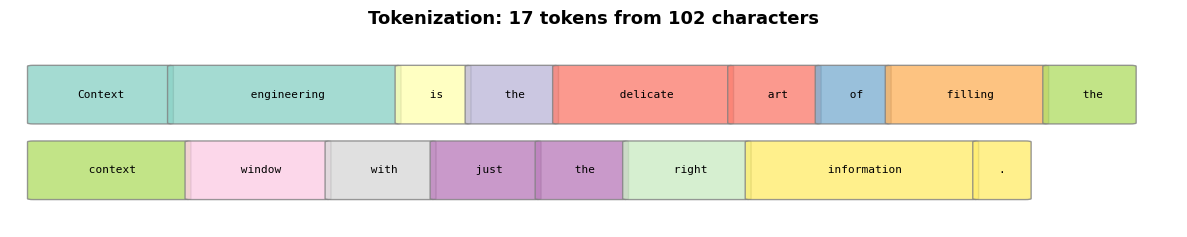

In [4]:
def visualize_tokens(text: str, max_display: int = 40):
    """Show how tiktoken breaks a string into individual tokens."""
    encoder = tiktoken.get_encoding("cl100k_base")
    token_ids = encoder.encode(text)
    tokens = [encoder.decode([tid]) for tid in token_ids]

    # Color each token differently for visibility
    colors = plt.cm.Set3(np.linspace(0, 1, min(len(tokens), max_display)))

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Tokenization: {len(tokens)} tokens from {len(text)} characters',
                 fontsize=13, fontweight='bold', pad=10)

    x_pos = 0.02
    y_pos = 0.7
    for i, (token, color) in enumerate(zip(tokens[:max_display], colors)):
        display = repr(token)[1:-1]  # Show whitespace clearly
        text_width = max(len(display) * 0.015, 0.03)

        rect = mpatches.FancyBboxPatch(
            (x_pos, y_pos - 0.15), text_width + 0.01, 0.3,
            boxstyle="round,pad=0.005", facecolor=color, edgecolor='gray', alpha=0.8
        )
        ax.add_patch(rect)
        ax.text(x_pos + (text_width + 0.01) / 2, y_pos, display,
                ha='center', va='center', fontsize=8, fontfamily='monospace')

        x_pos += text_width + 0.015
        if x_pos > 0.95:
            x_pos = 0.02
            y_pos -= 0.4
            if y_pos < 0:
                break

    if len(tokens) > max_display:
        ax.text(0.5, 0.05, f'... and {len(tokens) - max_display} more tokens',
                ha='center', va='center', fontsize=10, style='italic', color='gray')

    plt.tight_layout()
    plt.show()

# Visualize tokenization of a technical sentence
visualize_tokens("Context engineering is the delicate art of filling the context window with just the right information.")

Notice how the tokenizer handles code differently - variable names get split into subwords, punctuation often gets it own token, and numbers may be chunked in unexpected ways. This is why exact token counting matters when you are working close to the limits of a context window

## 4. The Mathematics: Token Budget Equation

Now that we have intuition, let us formalize. The total context window of an LLM is divided as:

$$T_{\text{total}} = T_{\text{system}} + T_{\text{history}} + T_{\text{RAG}} + T_{\text{tools}} + T_{\text{user}} + T_{\text{reserved}}$$

For a 128K-token model (like GPT-4-Turbo), a typical allocation looks like:

$$128{,}000 = 2{,}000 + 20{,}000 + 60{,}000 + 10{,}000 + 1{,}000 + 35{,}000$$

What does each term mean computationally?

- **$T_{\text{system}}$**: The instructions you give the model. These are present in *every* API call, so keeping them concise directly saves budget.
- **$T_{\text{history}}$**: Past conversation turns. In a chatbot, this grows with each exchange — you must decide when to summarize or truncate.
- **$T_{\text{RAG}}$**: Retrieved documents. This is typically the *largest* consumer. If your vector search returns too much, you blow the budget here.
- **$T_{\text{tools}}$**: Results from function calls (e.g., a database query returning JSON). Often overlooked in budgeting.
- **$T_{\text{user}}$**: The current user message. Usually small, but can be large if the user pastes a document.
- **$T_{\text{reserved}}$**: Space for the model's response. **If you don't reserve enough, the output gets truncated mid-sentence.**

The key insight: **these components compete for a fixed resource.** Increasing one means decreasing another.

In [5]:
DEFAULT_BUDGET = {
    "System_Prompt": 2_000,
    "Conversation History": 20_000,
    "Retrieved Context (RAG)": 60_000,
    "Tool Results": 10_000,
    "User Messages": 1_000,
    "Reserved for Output": 35_000,
}

COMPONENT_COLORS = {
    "System Prompt":       "#4C72B0",
    "Conversation History": "#55A868",
    "Retrieved Context (RAG)": "#C44E52",
    "Tool Results":        "#8172B2",
    "User Message":        "#CCB974",
    "Reserved for Output": "#64B5CD",
}

MODEL_LIMITS = {
    "GPT-3.5 (4K)":       4_096,
    "GPT-4 (32K)":        32_768,
    "GPT-4 Turbo (128K)": 128_000,
    "Gemini 1.5 Pro (1M)": 1_000_000,
}

def total_usage(budget):
  return sum(budget.values())
budget_total = total_usage(DEFAULT_BUDGET)
print(f"Total budget: {budget_total:,} tokens")
print(f"Target model: 128K")
print(f"Match: {'✅ Exact fit!' if budget_total == 128_000 else '❌ Mismatch!'}")



Total budget: 128,000 tokens
Target model: 128K
Match: ✅ Exact fit!


Time to get your hands dirty. Implement the `estimate_tokens` function below. It should:

1. Accept a text string and an optional `method` parameter
2. When `method="rough"`, return the ~4 chars/token estimate
3. When `method="exact"`, use tiktoken
4. When `method="both"`, return a dictionary with both estimates

This is the kind of utility function you will use in every context engineering project.

In [6]:
def estimate_tokens(text, method):
  # Corrected typo: changed 'c100k_base' to 'cl100k_base'
  encoder = tiktoken.get_encoding('cl100k_base')
  if not text:
    if method == "both":
      return {"rough":0, "exact":0}
    return 0

  exact = len(encoder.encode(text))
  rough = len(text)//4

  if method == 'rough':
    return rough
  elif method == 'exact':
    return exact
  else:
    return {'rough':rough,'exact':exact}

test_text = "The transformer architecture revolutionized natural language processing in 2017."

rough_result = estimate_tokens(test_text, method="rough")
exact_result = estimate_tokens(test_text, method="exact")
both_result = estimate_tokens(test_text, method="both")

print(f"   Test text: '{test_text}'")
print(f"   Rough estimate: {rough_result} tokens")
print(f"   Exact count:    {exact_result} tokens")
print(f"   Both:           {both_result}")

   Test text: 'The transformer architecture revolutionized natural language processing in 2017.'
   Rough estimate: 20 tokens
   Exact count:    13 tokens
   Both:           {'rough': 20, 'exact': 13}


## 6. 📊 Visualization Checkpoint 2: The Context Window Budget

Now let us visualize *where* your tokens go. This is the single most important diagram in context engineering — a stacked bar chart showing how each component fills (or overfills) the context window.

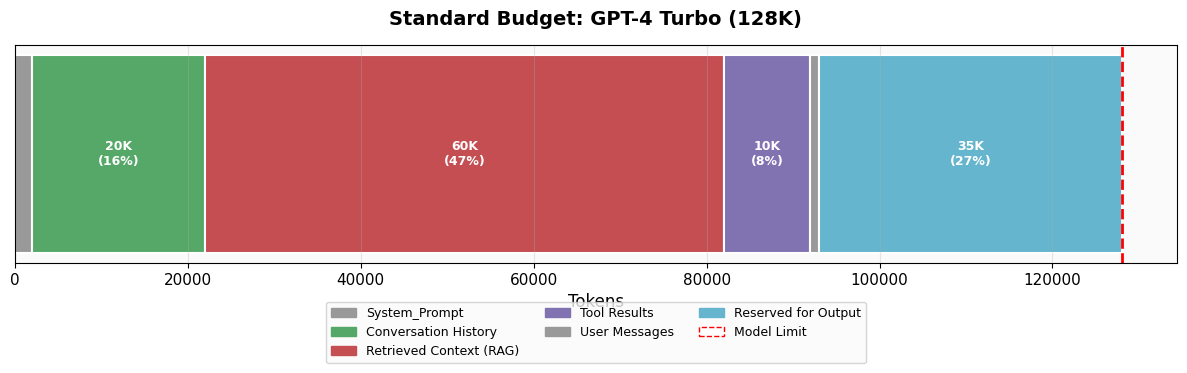


Total: 128,000 / 128,000 tokens — ✅ Within budget


In [7]:
def plot_context_budget(budget: Dict[str, int], model_limit: int,
                         title: str = "Context Window Budget Breakdown"):
    """Visualize a token budget as a stacked horizontal bar chart.

    Shows each component's allocation and whether the total exceeds the model limit.
    """
    components = list(budget.keys())
    values = list(budget.values())
    colors = [COMPONENT_COLORS.get(c, '#999999') for c in components]
    total = sum(values)

    fig, ax = plt.subplots(figsize=(12, 4))

    # Draw stacked horizontal bars
    left = 0
    bars = []
    for comp, val, color in zip(components, values, colors):
        bar = ax.barh(0, val, left=left, color=color, edgecolor='white',
                      linewidth=1.5, height=0.5)
        bars.append(bar)

        # Label inside the bar if there's room
        if val / model_limit > 0.05:
            pct = val / total * 100
            ax.text(left + val / 2, 0, f"{val // 1000}K\n({pct:.0f}%)",
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        left += val

    # Model limit line
    ax.axvline(x=model_limit, color='red', linewidth=2, linestyle='--', label=f'Model Limit ({model_limit // 1000}K)')

    # Overflow zone
    if total > model_limit:
        overflow = total - model_limit
        ax.axvspan(model_limit, total, alpha=0.15, color='red')
        ax.text(model_limit + overflow / 2, 0.35, f'⚠️ OVERFLOW\n{overflow // 1000}K tokens',
                ha='center', va='center', fontsize=10, color='red', fontweight='bold')

    ax.set_xlim(0, max(total, model_limit) * 1.05)
    ax.set_yticks([])
    ax.set_xlabel('Tokens', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Legend
    legend_patches = [mpatches.Patch(color=color, label=comp)
                      for comp, color in zip(components, colors)]
    legend_patches.append(mpatches.Patch(facecolor='white', edgecolor='red',
                                          linestyle='--', label=f'Model Limit'))
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=3, fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()

    # Print summary
    status = "✅ Within budget" if total <= model_limit else f"❌ Over budget by {total - model_limit:,} tokens"
    print(f"\nTotal: {total:,} / {model_limit:,} tokens — {status}")

# Visualize the default 128K budget
plot_context_budget(DEFAULT_BUDGET, model_limit=128_000,
                    title="Standard Budget: GPT-4 Turbo (128K)")

Look at how RAG dominates the budget — nearly half of the entire context window. This is why retrieval quality matters so much. If your retriever returns irrelevant documents, you are wasting the most valuable real estate in the window.

Also notice that the output reservation (35K) is substantial. A shorter expected response means more room for input context.

## 7. What Happens When Things Go Wrong?

Let us simulate a realistic scenario: your RAG pipeline returns **80K tokens** instead of the budgeted 60K. What happens?

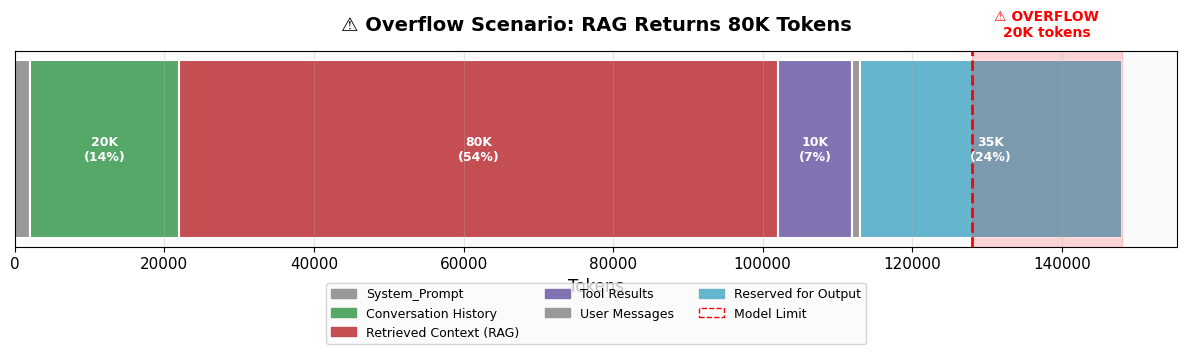


Total: 148,000 / 128,000 tokens — ❌ Over budget by 20,000 tokens


In [8]:
# Scenario: RAG returns more than expected
overflow_budget = DEFAULT_BUDGET.copy()
overflow_budget["Retrieved Context (RAG)"] = 80_000  # 20K more than planned

plot_context_budget(overflow_budget, model_limit=128_000,
                    title="⚠️ Overflow Scenario: RAG Returns 80K Tokens")

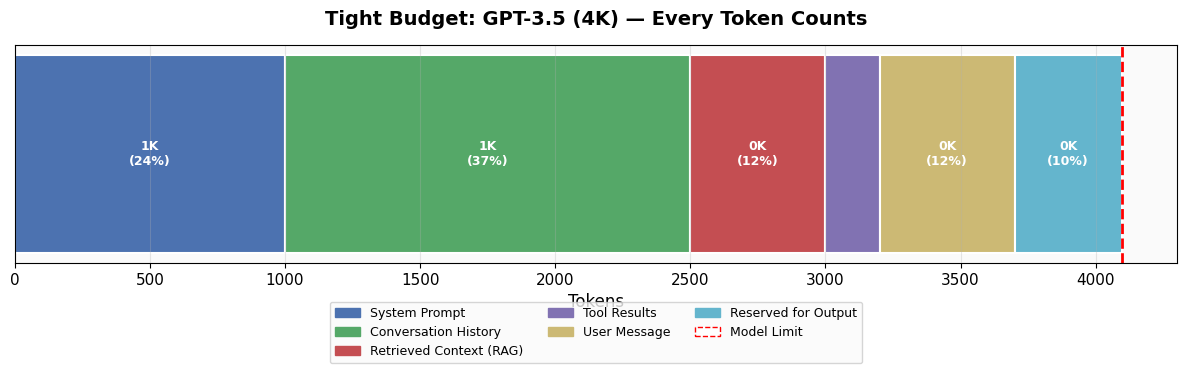


Total: 4,096 / 4,096 tokens — ✅ Within budget


In [9]:
# Let's also see: what if we try to cram this into a smaller model?
small_budget = {
    "System Prompt":       1_000,
    "Conversation History": 1_500,
    "Retrieved Context (RAG)": 500,
    "Tool Results":        200,
    "User Message":        500,
    "Reserved for Output": 396,
}

plot_context_budget(small_budget, model_limit=4_096,
                    title="Tight Budget: GPT-3.5 (4K) — Every Token Counts")

🤔 **Think about it:** With only 4K tokens, you can barely fit a system prompt and a short conversation. This is why the jump from 4K to 128K models was so transformative — it unlocked RAG, multi-turn conversations, and tool use all at once.

But even with 1M tokens (Gemini 1.5 Pro), budgeting still matters. More context means more latency, more cost, and more chances for the model to get confused by irrelevant information. **Bigger is not always better.**

## 8. 📊 Visualization Checkpoint 3: Multi-Model Comparison

Let us see how the same application's needs map onto different model sizes. This is a question every developer faces: "Which model do I need for my use case?"

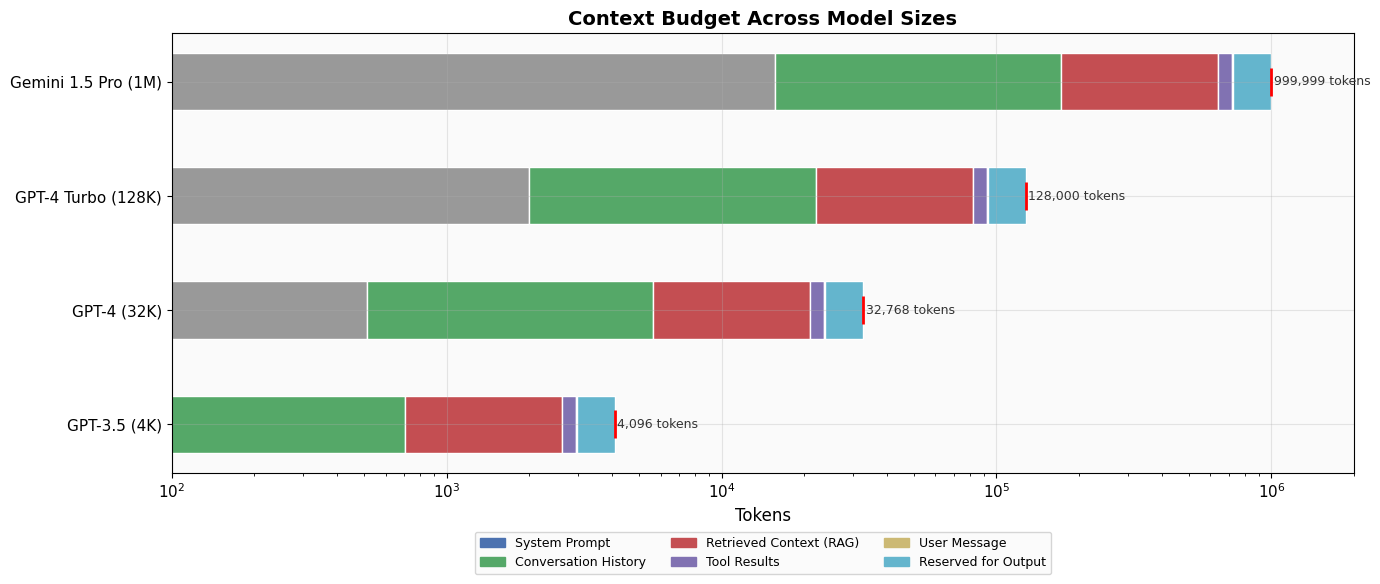

In [10]:
def scale_budget_to_model(base_budget: Dict[str, int], base_limit: int,
                           target_limit: int) -> Dict[str, int]:
    """Scale a budget proportionally to fit a different model size.

    Keeps the same relative proportions, but scales to the new limit.
    The system prompt and user message have minimums to stay functional.
    """
    ratio = target_limit / base_limit
    scaled = {}
    for component, tokens in base_budget.items():
        scaled_val = int(tokens * ratio)
        # Enforce minimums for critical components
        if component == "System Prompt":
            scaled_val = max(scaled_val, 200)
        elif component == "User Message":
            scaled_val = max(scaled_val, 100)
        elif component == "Reserved for Output":
            scaled_val = max(scaled_val, 200)
        scaled[component] = scaled_val
    return scaled


def plot_multi_model_comparison(base_budget: Dict[str, int],
                                 model_limits: Dict[str, int]):
    """Compare token budgets across multiple model sizes."""
    fig, ax = plt.subplots(figsize=(14, 6))

    model_names = list(model_limits.keys())
    y_positions = range(len(model_names))
    bar_height = 0.5

    for i, (model_name, limit) in enumerate(model_limits.items()):
        budget = scale_budget_to_model(base_budget, 128_000, limit)

        left = 0
        for comp, val in budget.items():
            color = COMPONENT_COLORS.get(comp, '#999999')
            ax.barh(i, val, left=left, color=color, edgecolor='white',
                    linewidth=1, height=bar_height)
            left += val

        # Model limit marker
        ax.plot(limit, i, 'r|', markersize=20, markeredgewidth=2)

        # Label total
        total = sum(budget.values())
        ax.text(total + limit * 0.02, i, f'{total:,.0f} tokens',
                va='center', fontsize=9, color='#333')

    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_names, fontsize=11)
    ax.set_xlabel('Tokens', fontsize=12)
    ax.set_title('Context Budget Across Model Sizes', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xlim(100, 2_000_000)

    # Legend
    legend_patches = [mpatches.Patch(color=color, label=comp)
                      for comp, color in COMPONENT_COLORS.items()]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.12),
              ncol=3, fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()

plot_multi_model_comparison(DEFAULT_BUDGET, MODEL_LIMITS)

💡 **Key takeaway from this visualization:** On a log scale, you can see that the 4K model barely registers. The jump from 32K to 128K is where RAG-heavy applications become feasible. And 1M tokens? That is enough to fit an entire codebase or book — but you pay for it in latency and cost.

In [11]:
def budget_calculator(budget: Dict[str, int], model_limit: int) -> Dict:
    """Analyze a token budget against a model's context limit.

    Returns a detailed analysis including:
    - Total usage and remaining capacity
    - Per-component percentages
    - Warnings for over-budget or tight allocations
    - Suggestions for rebalancing
    """
    total = sum(budget.values())
    remaining = model_limit - total
    utilization = total / model_limit * 100

    analysis = {
        "model_limit": model_limit,
        "total_used": total,
        "remaining": remaining,
        "utilization_pct": round(utilization, 1),
        "is_over_budget": total > model_limit,
        "components": {},
        "warnings": [],
        "suggestions": [],
    }

    # Analyze each component
    for comp, tokens in budget.items():
        pct_of_total = tokens / total * 100 if total > 0 else 0
        pct_of_limit = tokens / model_limit * 100
        analysis["components"][comp] = {
            "tokens": tokens,
            "pct_of_total": round(pct_of_total, 1),
            "pct_of_limit": round(pct_of_limit, 1),
        }

    # Generate warnings
    if total > model_limit:
        analysis["warnings"].append(
            f"⚠️ OVER BUDGET by {total - model_limit:,} tokens! "
            f"Reduce allocations by at least {(total - model_limit) / model_limit * 100:.1f}%."
        )

    output_budget = budget.get("Reserved for Output", 0)
    if output_budget < model_limit * 0.1:
        analysis["warnings"].append(
            f"⚠️ Output reservation ({output_budget:,}) is less than 10% of the window. "
            f"Responses may be truncated."
        )

    rag_budget = budget.get("Retrieved Context (RAG)", 0)
    if rag_budget > model_limit * 0.6:
        analysis["warnings"].append(
            f"⚠️ RAG allocation ({rag_budget:,}) exceeds 60% of the window. "
            f"Consider more aggressive retrieval filtering."
        )

    if remaining > model_limit * 0.2 and not analysis["is_over_budget"]:
        analysis["suggestions"].append(
            f"💡 You have {remaining:,} tokens unused ({remaining / model_limit * 100:.0f}%). "
            f"Consider expanding RAG or history allocation."
        )

    if utilization > 90 and not analysis["is_over_budget"]:
        analysis["suggestions"].append(
            f"💡 Running at {utilization:.0f}% utilization. Leave a small buffer for "
            f"variable-length inputs."
        )

    return analysis


def print_budget_report(analysis: Dict):
    """Pretty-print a budget analysis report."""
    print("=" * 60)
    print(f"  CONTEXT WINDOW BUDGET REPORT")
    print(f"  Model limit: {analysis['model_limit']:,} tokens")
    print("=" * 60)

    print(f"\n{'Component':<30} {'Tokens':>8} {'% Total':>8} {'% Limit':>8}")
    print("-" * 56)
    for comp, info in analysis["components"].items():
        print(f"{comp:<30} {info['tokens']:>8,} {info['pct_of_total']:>7.1f}% {info['pct_of_limit']:>7.1f}%")

    print("-" * 56)
    status = "🔴 OVER" if analysis["is_over_budget"] else "🟢 OK"
    print(f"{'TOTAL':<30} {analysis['total_used']:>8,} {'100.0':>7}% {analysis['utilization_pct']:>7.1f}%  {status}")
    print(f"{'Remaining':<30} {analysis['remaining']:>8,}")

    if analysis["warnings"]:
        print(f"\n{'WARNINGS':}")
        for w in analysis["warnings"]:
            print(f"  {w}")

    if analysis["suggestions"]:
        print(f"\n{'SUGGESTIONS':}")
        for s in analysis["suggestions"]:
            print(f"  {s}")

    print()

# Test with our default budget
report = budget_calculator(DEFAULT_BUDGET, 128_000)
print_budget_report(report)

  CONTEXT WINDOW BUDGET REPORT
  Model limit: 128,000 tokens

Component                        Tokens  % Total  % Limit
--------------------------------------------------------
System_Prompt                     2,000     1.6%     1.6%
Conversation History             20,000    15.6%    15.6%
Retrieved Context (RAG)          60,000    46.9%    46.9%
Tool Results                     10,000     7.8%     7.8%
User Messages                     1,000     0.8%     0.8%
Reserved for Output              35,000    27.3%    27.3%
--------------------------------------------------------
TOTAL                           128,000   100.0%   100.0%  🟢 OK
Remaining                             0

SUGGESTIONS
  💡 Running at 100% utilization. Leave a small buffer for variable-length inputs.



In [12]:
# Now test with the overflow scenario
overflow_budget = DEFAULT_BUDGET.copy()
overflow_budget["Retrieved Context (RAG)"] = 80_000

report_overflow = budget_calculator(overflow_budget, 128_000)
print_budget_report(report_overflow)

  CONTEXT WINDOW BUDGET REPORT
  Model limit: 128,000 tokens

Component                        Tokens  % Total  % Limit
--------------------------------------------------------
System_Prompt                     2,000     1.4%     1.6%
Conversation History             20,000    13.5%    15.6%
Retrieved Context (RAG)          80,000    54.1%    62.5%
Tool Results                     10,000     6.8%     7.8%
User Messages                     1,000     0.7%     0.8%
Reserved for Output              35,000    23.6%    27.3%
--------------------------------------------------------
TOTAL                           148,000   100.0%   115.6%  🔴 OVER
Remaining                       -20,000

WARNINGS
  ⚠️ OVER BUDGET by 20,000 tokens! Reduce allocations by at least 15.6%.
  ⚠️ RAG allocation (80,000) exceeds 60% of the window. Consider more aggressive retrieval filtering.



The Budget Optimizer

Here is the real challenge. Given a set of **constraints** (minimums and maximums for each component) and a total token budget, find the **optimal allocation**.

For example: "I need at least 40K for RAG and at least 20K for output. How should I distribute the rest?"

This is a constrained optimization problem. The simplest approach: satisfy all minimums first, then distribute the remaining tokens proportionally among components that have room to grow.

In [13]:

def budget_optimizer(
    constraints: Dict[str, Dict],
    max_tokens: int
) -> Dict[str, int]:
    """Find the optimal token allocation given constraints and a total budget.

    Args:
        constraints: Per-component constraints with min, max, and priority.
        max_tokens: Total context window size.

    Returns:
        Optimized allocation as {component_name: token_count}.
    """
    # Step 1: Assign minimums
    allocation = {comp: info["min"] for comp, info in constraints.items()}

    # Step 2: Calculate remaining
    remaining = max_tokens - sum(allocation.values())

    # Step 3: Check feasibility
    if remaining < 0:
        raise ValueError(
            f"Infeasible! Minimums sum to {sum(allocation.values()):,} "
            f"but model limit is {max_tokens:,}. "
            f"Over by {-remaining:,} tokens."
        )

    # Step 4: Distribute remaining by priority, respecting maxes
    # We may need multiple passes because when one component hits its max,
    # leftover tokens redistribute to others.
    components_with_room = {
        comp: info for comp, info in constraints.items()
        if allocation[comp] < info["max"]
    }

    while remaining > 0 and components_with_room:
        total_priority = sum(info["priority"] for info in components_with_room.values())
        if total_priority == 0:
            break

        distributed_this_round = 0
        newly_maxed = []

        for comp, info in components_with_room.items():
            share = int(remaining * (info["priority"] / total_priority))
            room = info["max"] - allocation[comp]
            addition = min(share, room)
            allocation[comp] += addition
            distributed_this_round += addition

            if allocation[comp] >= info["max"]:
                newly_maxed.append(comp)

        remaining -= distributed_this_round

        # Remove maxed-out components
        for comp in newly_maxed:
            del components_with_room[comp]

        # Safety: if no progress was made, break to avoid infinite loop
        if distributed_this_round == 0:
            break

    # Step 5: Any leftover goes to output reservation
    if remaining > 0:
        if "Reserved for Output" in allocation:
            allocation["Reserved for Output"] += remaining
        else:
            allocation["Reserved for Output"] = remaining

    return allocation


# ============ VERIFICATION ============

test_constraints = {
    "System Prompt":       {"min": 1_000, "max": 3_000,  "priority": 0.1},
    "Conversation History": {"min": 5_000, "max": 30_000, "priority": 0.2},
    "Retrieved Context (RAG)": {"min": 40_000, "max": 70_000, "priority": 0.4},
    "Tool Results":        {"min": 2_000, "max": 15_000, "priority": 0.1},
    "User Message":        {"min": 500,   "max": 2_000,  "priority": 0.05},
    "Reserved for Output": {"min": 20_000,"max": 50_000, "priority": 0.15},
}

optimized = budget_optimizer(test_constraints, max_tokens=128_000)

print("✅ Optimized Budget Allocation:")
print(f"{'Component':<30} {'Tokens':>10} {'Min':>8} {'Max':>8}")
print("-" * 58)
for comp, tokens in optimized.items():
    info = test_constraints[comp]
    status = "✓" if info["min"] <= tokens <= info["max"] else "✗"
    print(f"{comp:<30} {tokens:>10,} {info['min']:>8,} {info['max']:>8,}  {status}")

total = sum(optimized.values())
print("-" * 58)
print(f"{'Total':<30} {total:>10,}")
print(f"\n{'Budget used:':<30} {total:,} / 128,000 ({total/128_000*100:.1f}%)")
assert total <= 128_000, f"Over budget! {total:,} > 128,000"
assert all(optimized[c] >= test_constraints[c]["min"] for c in test_constraints), "Minimums violated!"
print("✅ All constraints satisfied!")

✅ Optimized Budget Allocation:
Component                          Tokens      Min      Max
----------------------------------------------------------
System Prompt                       3,000    1,000    3,000  ✓
Conversation History               18,176    5,000   30,000  ✓
Retrieved Context (RAG)            66,352   40,000   70,000  ✓
Tool Results                        8,588    2,000   15,000  ✓
User Message                        2,000      500    2,000  ✓
Reserved for Output                29,884   20,000   50,000  ✓
----------------------------------------------------------
Total                             128,000

Budget used:                   128,000 / 128,000 (100.0%)
✅ All constraints satisfied!


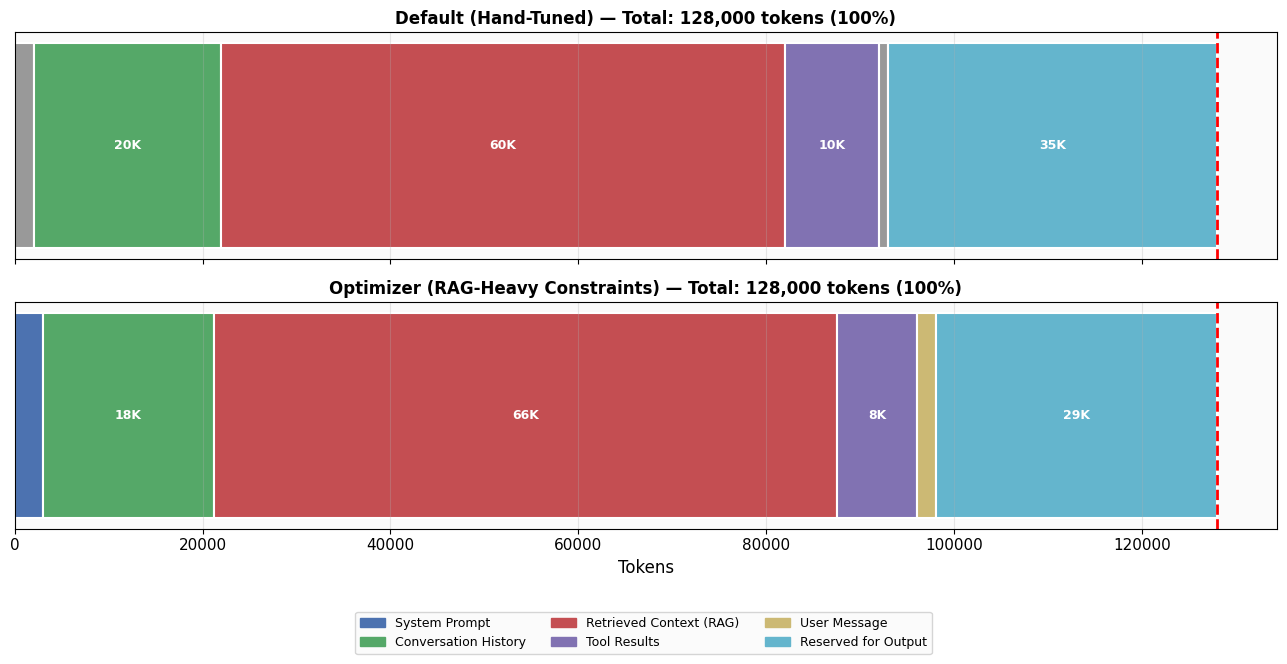

In [14]:
def plot_budget_comparison(budgets: Dict[str, Dict[str, int]], model_limit: int):
    """Compare multiple budget allocations side by side."""
    fig, axes = plt.subplots(len(budgets), 1, figsize=(13, 3 * len(budgets)),
                             sharex=True)
    if len(budgets) == 1:
        axes = [axes]

    for ax, (budget_name, budget) in zip(axes, budgets.items()):
        total = sum(budget.values())
        left = 0

        for comp, val in budget.items():
            color = COMPONENT_COLORS.get(comp, '#999999')
            ax.barh(0, val, left=left, color=color, edgecolor='white',
                    linewidth=1.5, height=0.5)
            if val / model_limit > 0.04:
                ax.text(left + val / 2, 0, f"{val // 1000}K",
                        ha='center', va='center', fontsize=9,
                        fontweight='bold', color='white')
            left += val

        ax.axvline(x=model_limit, color='red', linewidth=2, linestyle='--')
        ax.set_yticks([])
        ax.set_title(f"{budget_name} — Total: {total:,} tokens ({total/model_limit*100:.0f}%)",
                     fontsize=12, fontweight='bold')
        ax.set_xlim(0, model_limit * 1.05)

    axes[-1].set_xlabel('Tokens', fontsize=12)

    legend_patches = [mpatches.Patch(color=color, label=comp)
                      for comp, color in COMPONENT_COLORS.items()]
    fig.legend(handles=legend_patches, loc='upper center',
               bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()

plot_budget_comparison({
    "Default (Hand-Tuned)": DEFAULT_BUDGET,
    "Optimizer (RAG-Heavy Constraints)": optimized,
}, model_limit=128_000)

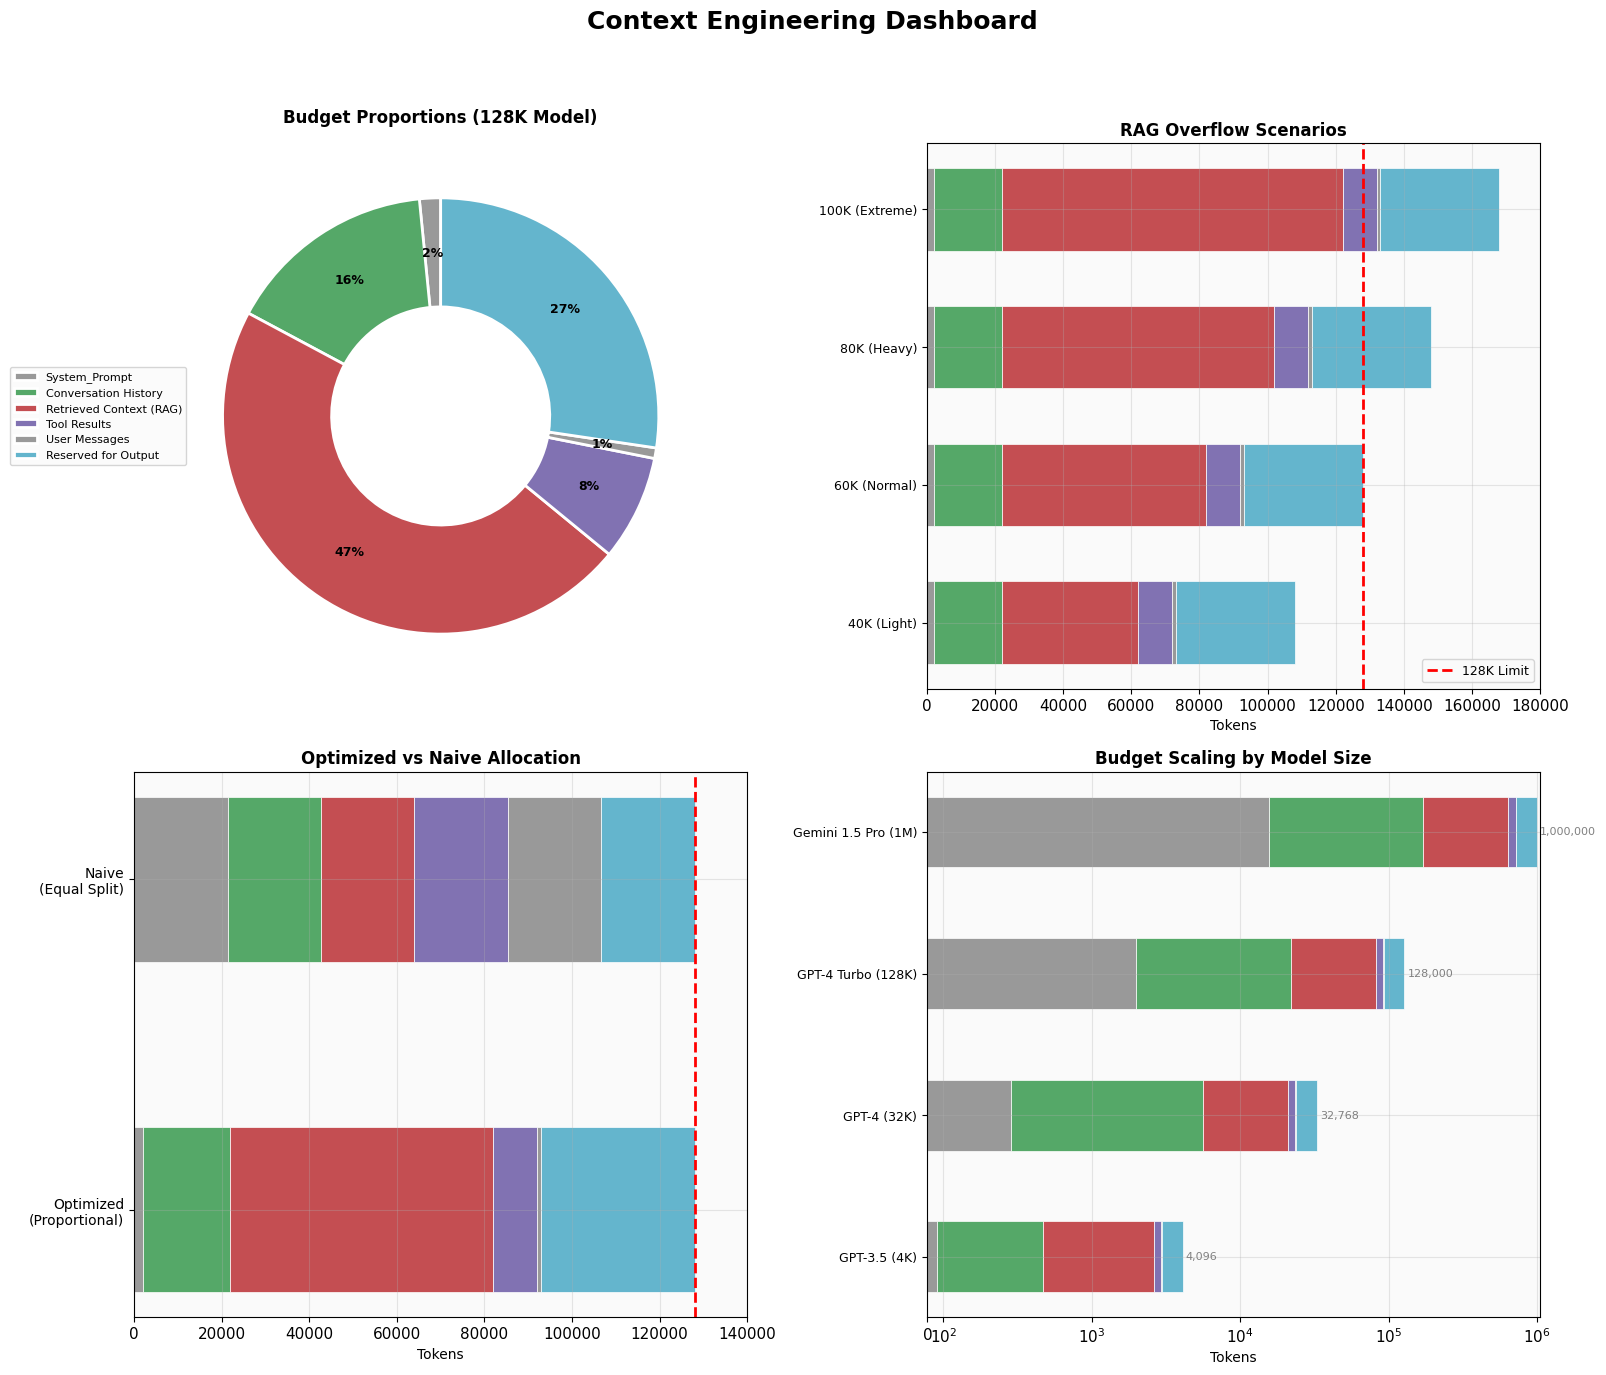

In [15]:
def create_dashboard(base_budget: Dict[str, int], model_limits: Dict[str, int]):
    """Create a comprehensive context engineering dashboard.

    Panel 1: Pie chart of budget components (proportions)
    Panel 2: What happens when RAG overflows (bar chart progression)
    Panel 3: Optimal vs suboptimal allocation comparison
    Panel 4: Multi-model scaling (how budget maps to different models)
    """
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle('Context Engineering Dashboard', fontsize=18, fontweight='bold', y=0.98)

    # ── Panel 1: Budget Proportions (Pie) ──
    ax1 = fig.add_subplot(2, 2, 1)
    components = list(base_budget.keys())
    values = list(base_budget.values())
    colors = [COMPONENT_COLORS.get(c, '#999') for c in components]

    wedges, texts, autotexts = ax1.pie(
        values, labels=None, autopct='%1.0f%%', colors=colors,
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')

    ax1.set_title('Budget Proportions (128K Model)', fontsize=12, fontweight='bold', pad=15)
    ax1.legend(components, loc='center left', bbox_to_anchor=(-0.3, 0.5), fontsize=8)

    # ── Panel 2: RAG Overflow Progression ──
    ax2 = fig.add_subplot(2, 2, 2)

    rag_scenarios = [40_000, 60_000, 80_000, 100_000]
    scenario_labels = ['40K (Light)', '60K (Normal)', '80K (Heavy)', '100K (Extreme)']

    for i, (rag_val, label) in enumerate(zip(rag_scenarios, scenario_labels)):
        scenario = base_budget.copy()
        scenario["Retrieved Context (RAG)"] = rag_val

        left = 0
        for comp, val in scenario.items():
            color = COMPONENT_COLORS.get(comp, '#999')
            ax2.barh(i, val, left=left, color=color, edgecolor='white',
                     linewidth=0.5, height=0.6)
            left += val

    ax2.axvline(x=128_000, color='red', linewidth=2, linestyle='--', label='128K Limit')
    ax2.set_yticks(range(len(scenario_labels)))
    ax2.set_yticklabels(scenario_labels, fontsize=9)
    ax2.set_xlabel('Tokens', fontsize=10)
    ax2.set_title('RAG Overflow Scenarios', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.set_xlim(0, 180_000)

    # ── Panel 3: Optimal vs Suboptimal ──
    ax3 = fig.add_subplot(2, 2, 3)

    # "Suboptimal" = naive equal split
    equal_split = {comp: 128_000 // 6 for comp in base_budget.keys()}
    # Adjust to sum exactly to 128K
    diff = 128_000 - sum(equal_split.values())
    first_key = list(equal_split.keys())[0]
    equal_split[first_key] += diff

    allocations = {"Optimized\n(Proportional)": base_budget, "Naive\n(Equal Split)": equal_split}

    for j, (alloc_name, alloc) in enumerate(allocations.items()):
        left = 0
        for comp, val in alloc.items():
            color = COMPONENT_COLORS.get(comp, '#999')
            ax3.barh(j, val, left=left, color=color, edgecolor='white',
                     linewidth=0.5, height=0.5)
            left += val

    ax3.axvline(x=128_000, color='red', linewidth=2, linestyle='--')
    ax3.set_yticks(range(len(allocations)))
    ax3.set_yticklabels(list(allocations.keys()), fontsize=10)
    ax3.set_xlabel('Tokens', fontsize=10)
    ax3.set_title('Optimized vs Naive Allocation', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 140_000)

    # ── Panel 4: Multi-Model Scaling ──
    ax4 = fig.add_subplot(2, 2, 4)

    model_names = list(model_limits.keys())
    model_totals = list(model_limits.values())

    # For each model, show how much of the default budget fits
    for i, (name, limit) in enumerate(model_limits.items()):
        scaled = scale_budget_to_model(base_budget, 128_000, limit)
        left = 0
        for comp, val in scaled.items():
            color = COMPONENT_COLORS.get(comp, '#999')
            ax4.barh(i, val, left=left, color=color, edgecolor='white',
                     linewidth=0.5, height=0.5)
            left += val

        ax4.text(sum(scaled.values()) * 1.05, i, f'{limit:,}',
                va='center', fontsize=8, color='gray')

    ax4.set_yticks(range(len(model_names)))
    ax4.set_yticklabels(model_names, fontsize=9)
    ax4.set_xlabel('Tokens', fontsize=10)
    ax4.set_title('Budget Scaling by Model Size', fontsize=12, fontweight='bold')
    ax4.set_xscale('symlog', linthresh=1000)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

create_dashboard(DEFAULT_BUDGET, MODEL_LIMITS)

In [16]:
# Final summary — one function to rule them all
def context_engineering_summary():
    """Print a quick-reference summary of context engineering principles."""
    print("""
╔══════════════════════════════════════════════════════════════╗
║              CONTEXT ENGINEERING CHEAT SHEET                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Token Estimation:                                           ║
║    • Rough: len(text) // 4                                   ║
║    • Exact: tiktoken.get_encoding("cl100k_base").encode(t)   ║
║                                                              ║
║  The Budget Equation:                                        ║
║    T_total = T_sys + T_hist + T_rag + T_tools + T_user + T_out ║
║                                                              ║
║  Typical 128K Allocation:                                    ║
║    System:  2K  │ History: 20K │ RAG: 60K                    ║
║    Tools:  10K  │ User:     1K │ Output: 35K                 ║
║                                                              ║
║  Key Rules:                                                  ║
║    1. Always reserve output space (≥10% of window)           ║
║    2. RAG is your biggest lever — control retrieval volume    ║
║    3. System prompts are taxed on every call — keep concise  ║
║    4. Measure, don't guess — use exact token counts          ║
║    5. Bigger window ≠ better — irrelevant context hurts      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
    """)

context_engineering_summary()
print("✅ Notebook complete! You now have the tools to budget any context window.")
print("📊 Next up: Part 2 — Prompt Architecture & Information Ordering")


╔══════════════════════════════════════════════════════════════╗
║              CONTEXT ENGINEERING CHEAT SHEET                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Token Estimation:                                           ║
║    • Rough: len(text) // 4                                   ║
║    • Exact: tiktoken.get_encoding("cl100k_base").encode(t)   ║
║                                                              ║
║  The Budget Equation:                                        ║
║    T_total = T_sys + T_hist + T_rag + T_tools + T_user + T_out ║
║                                                              ║
║  Typical 128K Allocation:                                    ║
║    System:  2K  │ History: 20K │ RAG: 60K                    ║
║    Tools:  10K  │ User:     1K │ Output: 35K                 ║
║                                                              ║
║  Key Rules:          